<a href="https://colab.research.google.com/github/LourdAbuHadid1/IE-332-Group-Assignments/blob/main/A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ipython-sql
%load_ext sql
%sql sqlite:///boilermaker_brews.db

In [2]:
%%sql
# Run this setup cell as provided. No package installation is needed.
from pathlib import Path
import sqlite3
import pandas as pd
from IPython.display import display

DB_PATH = Path("boilermaker_brews.db")

if not DB_PATH.exists():
    try:
        from google.colab import files
    except ImportError as exc:
        raise FileNotFoundError(
            "Place boilermaker_brews.db in the notebook's working folder."
        ) from exc
    print("Choose boilermaker_brews.db from the course files.")
    files.upload()

if not DB_PATH.exists():
    raise FileNotFoundError("boilermaker_brews.db was not uploaded.")

# These exercises only read data; protect the uploaded database from changes.
conn = sqlite3.connect(DB_PATH.resolve().as_uri() + "?mode=ro", uri=True)


class SQLResult(list):
    """Query rows and the information needed by the provided self-checks."""
    def __init__(self, frame, sql):
        super().__init__(frame.itertuples(index=False, name=None))
        self.keys = list(frame.columns)
        self.frame = frame
        self.sql = sql


def _sql_magic(line, cell):
    """Run SQL and display its result; %%sql q1 << also saves it as q1."""
    parts = line.split()
    if parts and (
        not parts[0].isidentifier()
        or len(parts) > 2
        or (len(parts) == 2 and parts[1] != "<<")
    ):
        raise ValueError("Use %%sql or a capture header such as %%sql q1 <<.")
    target = parts[0] if parts else None
    if target:
        # A failed rerun must not leave an earlier answer available to the check.
        get_ipython().user_ns[target] = None
    with conn:
        cursor = conn.execute(cell)
        if cursor.description is None:
            raise ValueError("Write a SELECT or WITH query below the %%sql header.")
        frame = pd.DataFrame(cursor.fetchall(), columns=[col[0] for col in cursor.description])
    if target:
        get_ipython().user_ns[target] = SQLResult(frame, cell)
    display(frame)


get_ipython().register_magic_function(_sql_magic, "cell", "sql")


def _sql_line_magic(line):
    _sql_magic("", line)


get_ipython().register_magic_function(_sql_line_magic, "line", "sql")
print(f"Connected to {DB_PATH.name}. The %%sql command is ready.")


 * sqlite:///boilermaker_brews.db
(sqlite3.OperationalError) unrecognized token: "#"
[SQL: # Run this setup cell as provided. No package installation is needed.
from pathlib import Path
import sqlite3
import pandas as pd
from IPython.display import display

DB_PATH = Path("boilermaker_brews.db")

if not DB_PATH.exists():
    try:
        from google.colab import files
    except ImportError as exc:
        raise FileNotFoundError(
            "Place boilermaker_brews.db in the notebook's working folder."
        ) from exc
    print("Choose boilermaker_brews.db from the course files.")
    files.upload()

if not DB_PATH.exists():
    raise FileNotFoundError("boilermaker_brews.db was not uploaded.")

# These exercises only read data; protect the uploaded database from changes.
conn = sqlite3.connect(DB_PATH.resolve().as_uri() + "?mode=ro", uri=True)


class SQLResult(list):
    """Query rows and the information needed by the provided self-checks."""
    def __init__(self, frame, sql):
 

Display the tables and the columns in the database

In [7]:
%%sql

SELECT
m.name AS table_name,
p.name AS column_name,
p.type AS data_type
FROM sqlite_master AS m
JOIN pragma_table_info(m.name) AS p
WHERE m.type = 'table'
AND m.name NOT LIKE 'sqlite_%'
ORDER BY m.name, p.cid;

 * sqlite:///boilermaker_brews.db
Done.


table_name,column_name,data_type
customers,customer_id,INTEGER
customers,name,TEXT
customers,joined_date,TEXT
customers,loyalty_tier,TEXT
employees,employee_id,INTEGER
employees,name,TEXT
employees,store_id,INTEGER
employees,hired_date,TEXT
employees,hourly_wage,REAL
order_items,order_id,INTEGER


In [3]:
%sql sqlite:///boilermaker_brews.db

In [4]:
%config SqlMagic.style = 'PLAIN_COLUMNS'

# Question 1

In [5]:
%%sql df_rev <<

-- Sorting by revenue
SELECT
    p.category,
    SUM(o.unit_price * o.quantity) AS revenue,
    SUM(o.quantity) AS units
FROM products AS p
JOIN order_items AS o
    ON p.product_id = o.product_id
GROUP BY p.category
ORDER BY revenue DESC;

 * sqlite:///boilermaker_brews.db
Done.
Returning data to local variable df_rev


In [6]:
print(df_rev)

+----------+-----------+-------+
| category |  revenue  | units |
+----------+-----------+-------+
| espresso | 197025.25 | 41410 |
|   brew   |  67355.3  | 18175 |
|   tea    |  44795.5  | 12196 |
|  pastry  |  39935.3  | 13168 |
|   food   |  21793.25 |  2963 |
|  merch   |   3310.0  |  334  |
+----------+-----------+-------+


In [19]:
%%sql df_units <<

-- Sorting by units
SELECT
    p.category,
    SUM(o.unit_price * o.quantity) AS revenue,
    SUM(o.quantity) AS units
FROM products AS p
JOIN order_items AS o
    ON p.product_id = o.product_id
GROUP BY p.category
ORDER BY units DESC;

 * sqlite:///boilermaker_brews.db
Done.
Returning data to local variable df_units


In [20]:
print(df_units)

+----------+-----------+-------+
| category |  revenue  | units |
+----------+-----------+-------+
| espresso | 197025.25 | 41410 |
|   brew   |  67355.3  | 18175 |
|  pastry  |  39935.3  | 13168 |
|   tea    |  44795.5  | 12196 |
|   food   |  21793.25 |  2963 |
|  merch   |   3310.0  |  334  |
+----------+-----------+-------+


the two categories that switch their relative order are "pastry" and "tea"

when ordering by revenue:
tea: $44795.50
pastry: $39935.30
tea ranks higher because it generated more total money

when ordering by units:
pastry: 13168 units
tea: 12196 units
pastry ranks higher because more individual pastry items were sold

# ERD

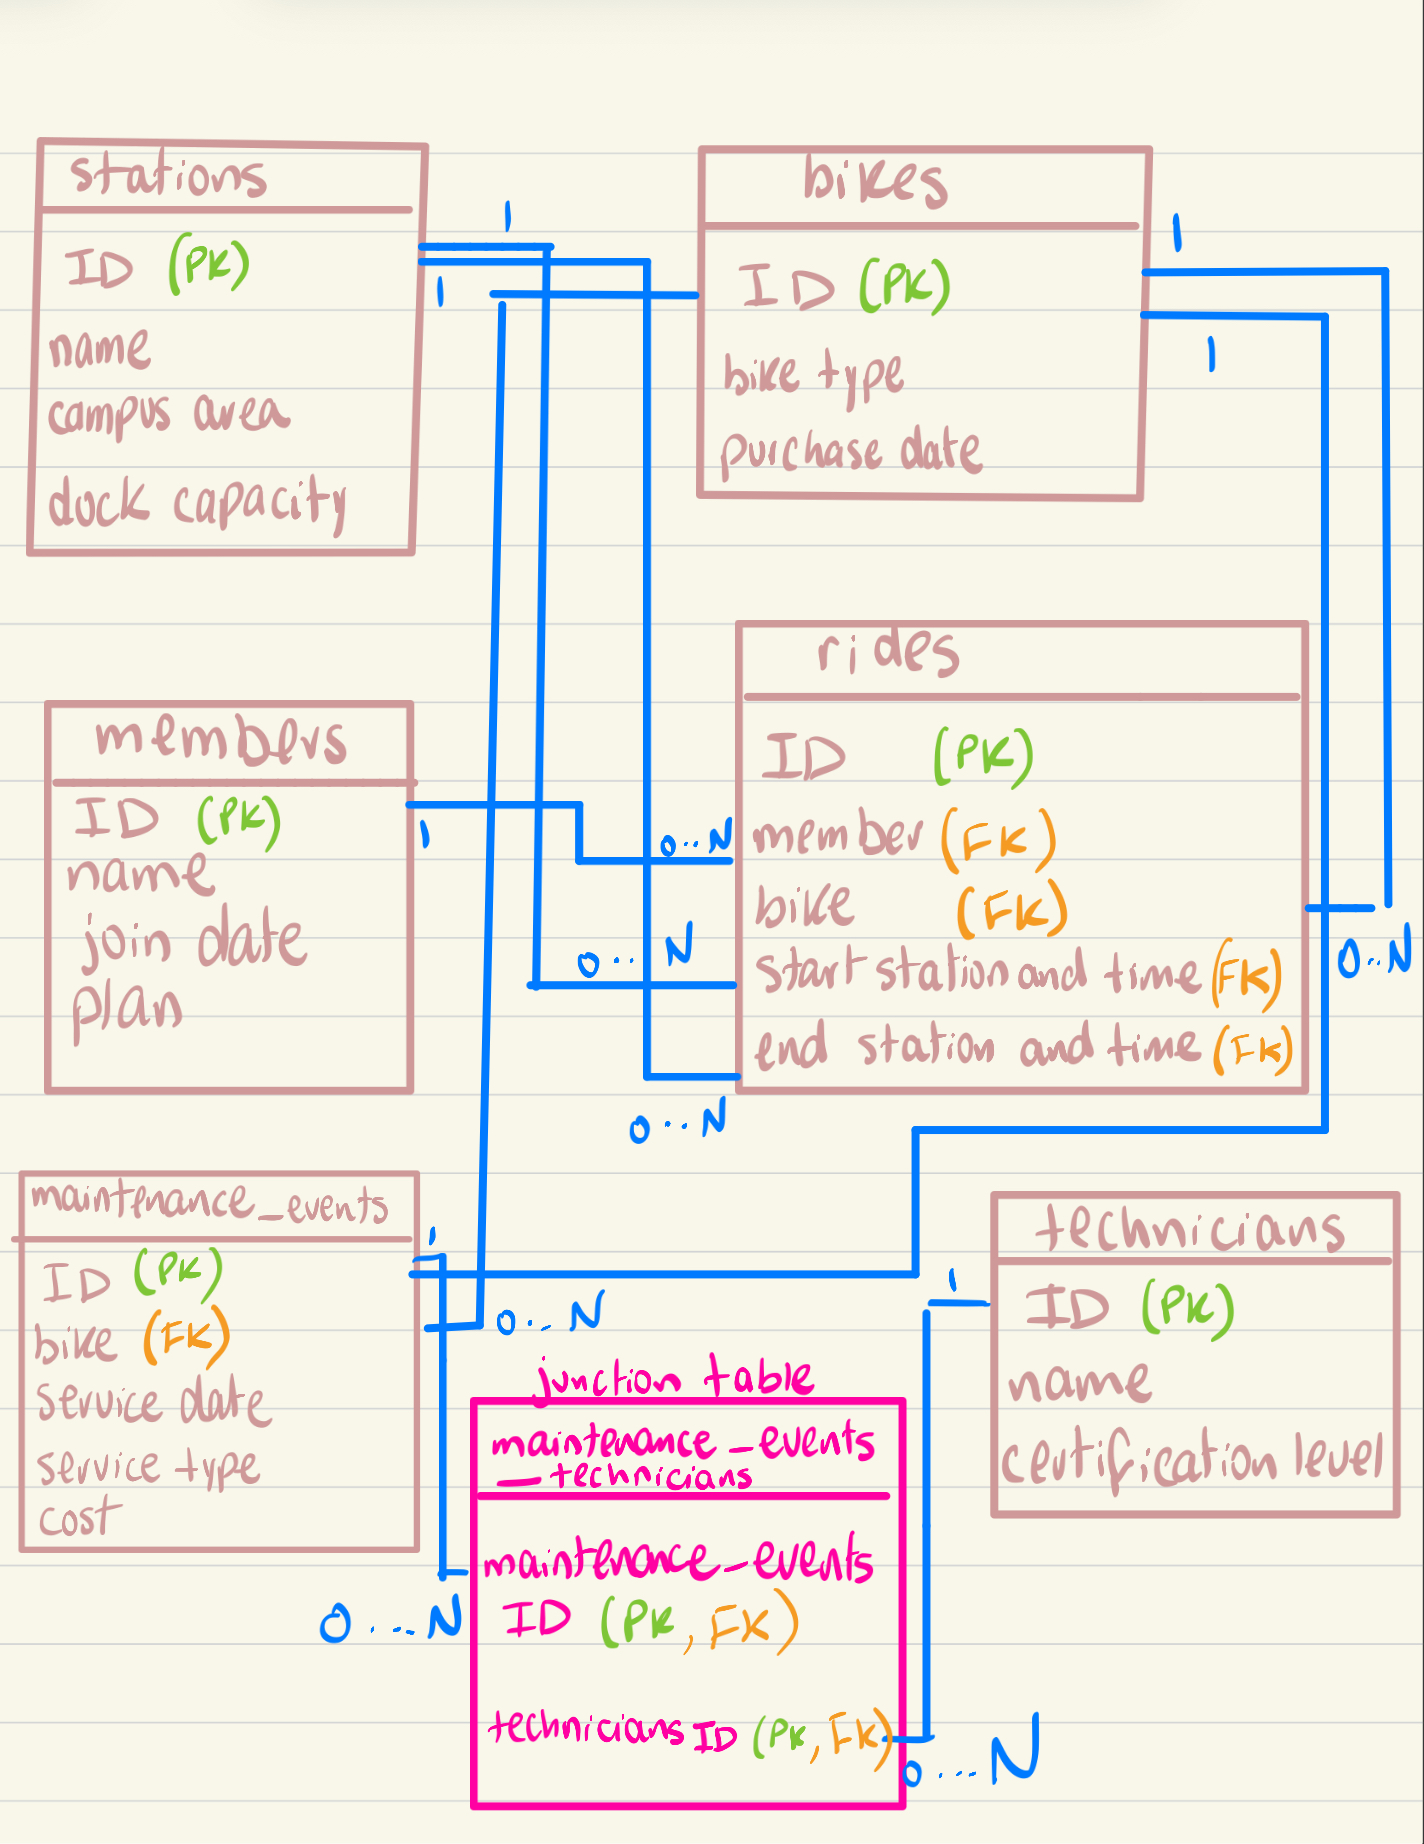



Grains:

stations: one row represents one station

bikes: one row represents one bike

members: one row represents one member

rides: one row represents one bike ride

maintenance_events:one row represents one maintenance event for a bike

technicians:one row represents one technician

maintenance_events_technicians: one row represents a pairing of one maintenance event with one technician
